In [278]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import mglearn

# Linear Regression

w[0]: 0.393906  b: -0.031804


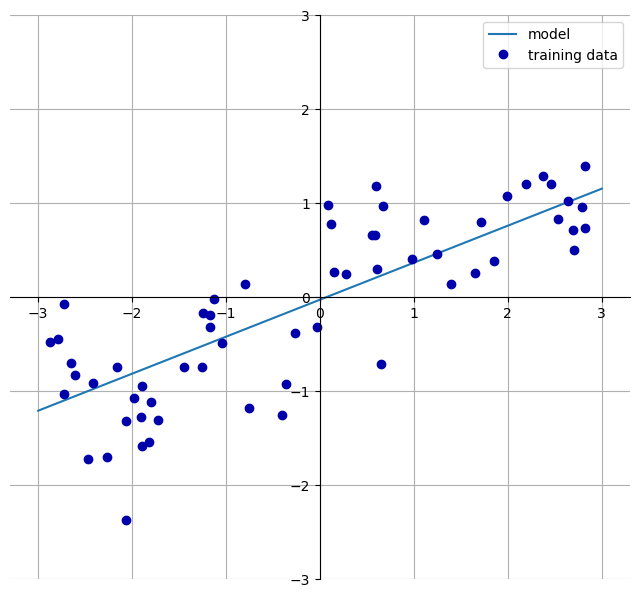

In [279]:
mglearn.plots.plot_linear_regression_wave()

In [280]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
X, y = mglearn.datasets.make_wave(n_samples=60)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
lr = LinearRegression().fit(X_train, y_train)

In [281]:
print("lr.coef_: {}".format(lr.coef_))
print("lr.intercept_: {}".format(lr.intercept_))

lr.coef_: [0.39390555]
lr.intercept_: -0.031804343026759746


In [282]:
print("Training set score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))

Training set score: 0.67
Test set score: 0.66


In [283]:
X, y = mglearn.datasets.load_extended_boston()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
lr = LinearRegression().fit(X_train, y_train)

In [284]:
print("Training set score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))

Training set score: 0.95
Test set score: 0.61


In [285]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
X, y = load_diabetes(return_X_y=True)
X = X[:, [2]] # Using only one feature
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 20, shuffle=False)

In [286]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression().fit(X_train, y_train)

In [287]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = regressor.predict(X_test)

print('Mean Squared Error: ', mean_squared_error(y_test, y_pred))
print('R^2 Score: ', r2_score(y_test, y_pred))

Mean Squared Error:  2548.07239872597
R^2 Score:  0.47257544798227147


In [288]:
print(regressor.coef_)
print(regressor.intercept_)

[938.23786125]
152.91886182616113


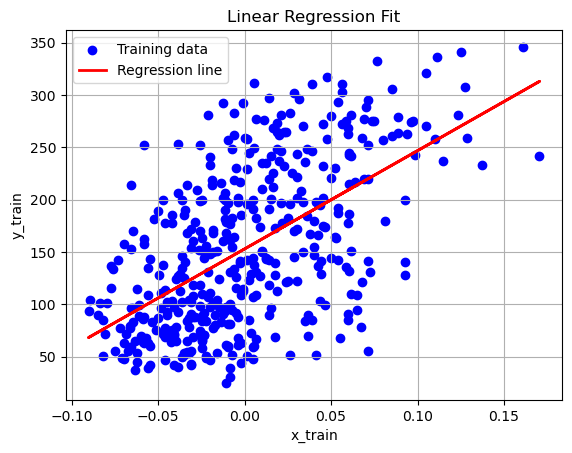

In [289]:
y_train_pred = regressor.predict(X_train)
# Plot
plt.scatter(X_train, y_train, color='blue', label='Training data')  # original points
plt.plot(X_train, y_train_pred, color='red', linewidth=2, label='Regression line')  # regression line
plt.xlabel('x_train')
plt.ylabel('y_train')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True)
plt.show()

In [290]:
from sklearn.linear_model import LinearRegression
reg_nnls = LinearRegression()
y_pred_nnls = reg_nnls.fit(X_train, y_train).predict(X_test)
r2_score_nnls = r2_score(y_test, y_pred)
print('NNLs R2 Score: ', r2_score_nnls)

NNLs R2 Score:  0.47257544798227147


In [291]:
from sklearn.linear_model import LinearRegression
reg_nnls = LinearRegression(positive=True)
y_pred_nnls = reg_nnls.fit(X_train, y_train).predict(X_test)
r2_score_nnls = r2_score(y_test, y_pred)
print('NNLs R2 Score: ', r2_score_nnls)

NNLs R2 Score:  0.47257544798227147


# Polynomial Linear Regression

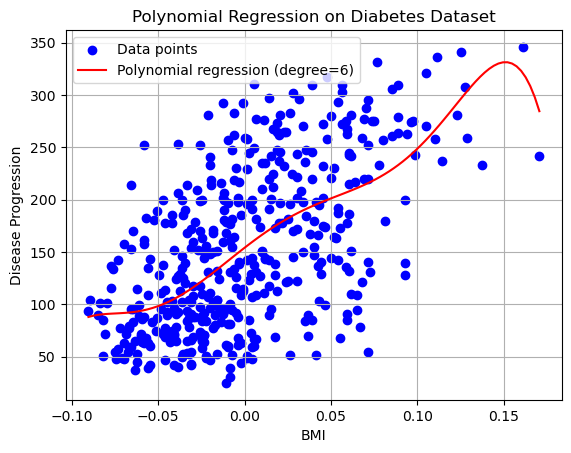

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

# 1. Load the Diabetes dataset
diabetes = load_diabetes()
X = diabetes.data[:, 2].reshape(-1, 1)  # Using a single feature (e.g., BMI)
y = diabetes.target  # Target: Disease progression

# 2. Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create a polynomial regression model with degree 5
degree = 6
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

# 4. Fit the model on the training data
model.fit(X_train, y_train)

# 5. Predict on the test data
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred = model.predict(X_plot)

# 6. Plot the original data and the polynomial regression curve
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X_plot, y_pred, color='red', label=f'Polynomial regression (degree={degree})')
plt.xlabel('BMI')
plt.ylabel('Disease Progression')
plt.title('Polynomial Regression on Diabetes Dataset')
plt.legend()
plt.grid(True)
plt.show()


In [49]:
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
print(r2_score(y_test, y_pred))

0.24887470953653823
